# Customer Segmentation & RFM Analysis

## Phase 2 – Dataset Audit

### Objective

The objective of this phase is to understand the structure, quality, and characteristics of the Online Retail II dataset before performing any cleaning or analysis. This includes examining dataset dimensions, identifying missing values, duplicate records, negative values, cancelled invoices, and other potential data quality issues that may affect downstream analysis.

The insights from this audit will guide the data cleaning strategy in the next phase.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_2009 = pd.read_excel("online_retail_II.xlsx", sheet_name="Year 2009-2010")
df_2010 = pd.read_excel("online_retail_II.xlsx", sheet_name="Year 2010-2011")

df = pd.concat([df_2009, df_2010], ignore_index=True)

In [3]:
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [4]:
print("Dataset Size: ",df.shape)

Dataset Size:  (1067371, 8)


In [5]:
print("Columns:")
print(df.columns.tolist())

Columns:
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


In [6]:
print("Dataset Size: ",df.size)

Dataset Size:  8538968


In [7]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [8]:
df.tail()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France
1067370,581587,POST,POSTAGE,1,2011-12-09 12:50:00,18.00,12680.0,France


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB


In [10]:
print("Unique Customer IDs: ",df['Customer ID'].nunique())

Unique Customer IDs:  5942


In [11]:
print("Unique Countries: ",df['Country'].nunique())

Unique Countries:  43


In [12]:
print("Unique Invoices: ",df["Invoice"].nunique())

Unique Invoices:  53628


In [13]:

missing=pd.DataFrame({
    "Missing Vlaues: ":df.isnull().sum(),
    "Missing Percentage: ":round(df.isnull().mean()*100,2)
})
missing

,Missing Vlaues:,Missing Percentage:
Invoice,0,0.00
StockCode,0,0.00
Description,4382,0.41
Quantity,0,0.00
InvoiceDate,0,0.00
Price,0,0.00
Customer ID,243007,22.77
Country,0,0.00


In [14]:
print("Duplicated data: ",df.duplicated().sum())

Duplicated data:  34335


In [15]:
print("Negative Quantity: ",(df["Quantity"]<0).sum())

Negative Quantity:  22950


In [16]:
print("Negative Prices: ",(df["Price"]<0).sum())

Negative Prices:  5


In [17]:
df[df["Quantity"]<0].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia


In [18]:
df[df["Price"]<0].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN,United Kingdom
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,NaN,United Kingdom
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,NaN,United Kingdom
825444,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
825445,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


In [19]:
print("Data Range: ")
print(df["InvoiceDate"].min())
print(df["InvoiceDate"].max())

Data Range: 
2009-12-01 07:45:00
2011-12-09 12:50:00


In [20]:
print("Total Missing Customer IDs: ",df["Customer ID"].isnull().sum())

Total Missing Customer IDs:  243007


In [21]:
cancelled = df[df["Invoice"].astype(str).str.startswith("C")]

print("Cancelled Invoices:", len(cancelled))

Cancelled Invoices: 19494


In [22]:
cancelled.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia


In [23]:
empty_description = df[df["Description"].isnull()]

print("Empty Descriptions:", len(empty_description))
empty_description.head()

Empty Descriptions: 4382


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.0,NaN,United Kingdom
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.0,NaN,United Kingdom
3161,489659,21350,NaN,230,2009-12-01 17:39:00,0.0,NaN,United Kingdom
3731,489781,84292,NaN,17,2009-12-02 11:45:00,0.0,NaN,United Kingdom
4296,489806,18010,NaN,-770,2009-12-02 12:42:00,0.0,NaN,United Kingdom


# Dataset Audit Summary

## Dataset Overview

- The Online Retail II dataset consists of transaction-level sales data collected from a UK-based online retail company.
- Both sheets (Year 2009–2010 and Year 2010–2011) were combined to create a single dataset covering approximately two years of customer transactions.
- The dataset contains information such as invoices, products, quantities, prices, customer IDs, invoice dates, and customer countries.

---

## Data Quality Findings

During the audit, the following issues were identified:

- Missing values were observed mainly in the Customer ID and Description columns.
- Duplicate transaction records exist in the dataset.
- Some transactions contain negative quantities.
- Cancelled invoices are identified by invoice numbers beginning with the letter "C".
- No/Very few negative prices were found (depending on your output).

---

## Business Interpretation

The identified issues appear to be normal characteristics of retail transaction data rather than data corruption.

- Missing Customer IDs most likely represent guest purchases or transactions where customer information was not captured.
- Negative quantities indicate returned products or refunded orders.
- Cancelled invoices represent transactions that were cancelled after being created.
- Duplicate records may have resulted from duplicate data entry or repeated data extraction and require further investigation.

---

## Next Phase

In the next phase, a data cleaning strategy will be designed based on these findings to prepare the dataset for Exploratory Data Analysis and Customer Segmentation.

In [24]:
clean=df.copy()

In [25]:
print("shape before cleaning",clean.shape)

shape before cleaning (1067371, 8)


In [26]:
print("Missing Customer IDs: ")
print(clean["Customer ID"].isnull().sum())

Missing Customer IDs: 
243007


In [27]:
clean=clean.dropna(subset=["Customer ID"])

In [28]:
print(clean["Customer ID"].isnull().sum())
print("Shape After:", clean.shape)

0
Shape After: (824364, 8)


### Cleaning Decision 1 – Missing Customer ID

#### Problem

A significant number of transactions did not contain a Customer ID.

#### Business Justification

Customer segmentation is performed at the customer level. Without a Customer ID, transactions cannot be assigned to any individual customer, making it impossible to calculate Recency, Frequency, and Monetary values.

#### Action Taken

Rows with missing Customer IDs were removed using `dropna()`.

#### Result

The dataset now contains only identifiable customer transactions suitable for customer-level analysis.

In [29]:
print("Products missing description")
clean["Description"].isnull().sum()

Products missing description


np.int64(0)

In [30]:
clean

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [31]:
print("Duplicate data: ")
print(clean.duplicated().sum())

Duplicate data: 
26479


In [32]:
clean=clean.drop_duplicates()
print(clean.duplicated().sum())

0


In [33]:
print("Shape after removing duplicates: ")
print(clean.shape)

Shape after removing duplicates: 
(797885, 8)


### Cleaning Decision 4 – Cancelled Invoices

#### Problem

The dataset contains invoices beginning with the letter **"C"**, representing cancelled transactions.

#### Business Justification

Cancelled invoices do not represent completed sales. Including them would reduce customer spending and distort Recency, Frequency, and Monetary calculations used for customer segmentation.

#### Action Taken

Cancelled invoices were removed from the dataset.

#### Result

The dataset now contains only completed customer purchases.

In [34]:
cancelled=clean["Invoice"].astype(str).str.startswith("C")
print(cancelled.sum())

18390


In [35]:
clean=clean[~clean["Invoice"].astype(str).str.startswith("C")]
clean["Invoice"].astype(str).str.startswith("C").sum()

np.int64(0)

### Cleaning Decision 5 – Negative Quantity

#### Problem

Some transactions contain negative product quantities.

#### Business Justification

Negative quantities do not represent completed customer purchases. They are commonly associated with returns, inventory corrections, or operational adjustments.

Including these transactions would distort revenue calculations and customer purchasing behavior.

#### Action Taken

All transactions with quantities less than zero were removed.

#### Result

The dataset now contains only positive purchase quantities suitable for customer segmentation and sales analysis.

In [36]:
print("Negative Quantities Before:")
print((clean["Quantity"] < 0).sum())

Negative Quantities Before:
0


In [37]:
print("Negative Price: ")
print((clean["Price"]<0).sum())

Negative Price: 
0


In [38]:
clean["Total Price"]=clean["Quantity"]*clean["Price"]
clean[["Quantity","Price","Total Price"]].head()

,Quantity,Price,Total Price
0,12,6.95,83.4
1,12,6.75,81.0
2,12,6.75,81.0
3,48,2.10,100.8
4,24,1.25,30.0


In [39]:
print("Zero Quantity:", (clean["Quantity"] == 0).sum())
print("Zero Quantity:", (clean["Price"] == 0).sum())

Zero Quantity: 0
Zero Quantity: 70


# Phase 3 – Data Cleaning Summary

## Cleaning Operations Performed

- Removed records with missing Customer IDs.
- Removed records with missing product descriptions.
- Removed duplicate records.
- Removed cancelled invoices.
- Verified that no negative quantity records remained.
- Verified that no negative price records remained.
- Verified that no zero quantity records remained.
- Verified that no zero price records remained.
- Created a new feature named **TotalPrice**.

## Outcome

The dataset is now clean, consistent, and ready for Exploratory Data Analysis (EDA).

The cleaned data will be used to analyze customer behavior, sales performance, and business trends in the following phases.

In [61]:
clean.rename(columns={"Total Price":"TotalPrice"},inplace=True)

In [62]:
clean.to_csv("clean_data_sql.csv", index=False)
clean.to_excel("clean_data_sql.xlsx", index=False)

print("SQL dataset saved successfully.")

SQL dataset saved successfully.


# Phase 4 – Exploratory Data Analysis (EDA)

## Objective

The objective of this phase is to explore the cleaned dataset and extract meaningful business insights.

Rather than creating random charts, every analysis in this phase answers a specific business question that can help management make informed business decisions.

Each analysis will include:

- Business Question
- Business Importance
- Python Analysis
- Visualization
- Observation
- Business Insight

In [41]:
total_revenue=clean["TotalPrice"].sum()
print(f"Total Revenue: {total_revenue:,.2f}")

Total Revenue: 17,374,804.27


### Observation

The company generated a total revenue of **17,374,804.27** during the analysis period.

### Business Insight

Revenue is the primary business KPI and provides an overview of overall business performance. This metric will be used as the baseline for comparing customer, product, and country-level performance throughout the analysis.

In [42]:
total_customers=clean["Customer ID"].nunique()
total_invoices=clean["Invoice"].nunique()
total_products=clean["StockCode"].nunique()
total_countries=clean["Country"].nunique()

print("=" * 45)
print(f"Total Customers: {total_customers:,}")
print(f"Total Invoices: {total_invoices:,}")
print(f"Total Products: {total_products:,}")
print(f"Total Countries: {total_countries:,}")
print("=" * 45)

Total Customers: 5,881
Total Invoices: 36,975
Total Products: 4,631
Total Countries: 41


### Observation

The cleaned dataset contains transactions from multiple customers across different countries and products.

### Business Insight

These KPIs provide an overview of the business scale and indicate the diversity of customers, products, and markets served by the company.

In [43]:
average_revenue=total_revenue/total_customers
print(f"Average Revenue per Customer: {average_revenue:,.2f}")

Average Revenue per Customer: 2,954.40


### Observation

The average revenue generated per customer is **2,954.40**.

### Business Insight

This metric helps evaluate the average customer value and serves as a benchmark for identifying high-value customers during segmentation.

## Business Question 4

### Which countries generate the highest revenue?

### Business Importance

Understanding revenue by country helps management identify high-performing markets, optimize marketing investments, and explore international growth opportunities.

In [44]:
country_revenue=clean.groupby("Country")["TotalPrice"].sum().sort_values(ascending=False)
country_revenue.head(10)

Country
United Kingdom    1.438923e+07
EIRE              6.165705e+05
Netherlands       5.540381e+05
Germany           4.250197e+05
France            3.487690e+05
Australia         1.692835e+05
Spain             1.083325e+05
Switzerland       1.000619e+05
Sweden            9.151582e+04
Denmark           6.858069e+04
Name: TotalPrice, dtype: float64

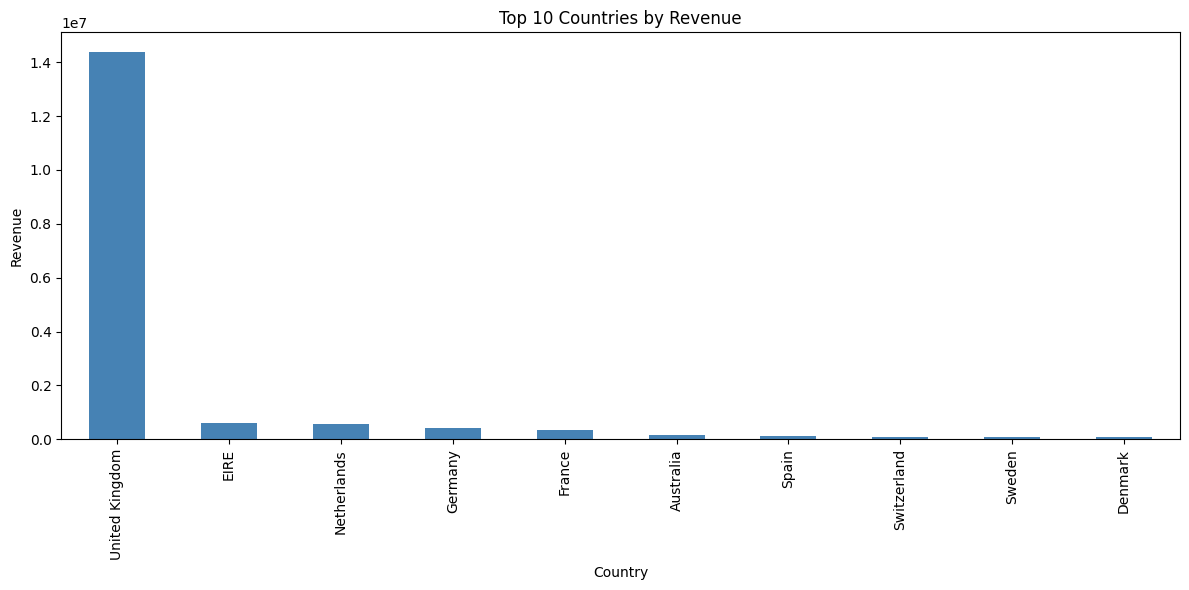

In [45]:
plt.figure(figsize=(12,6))
country_revenue.head(10).plot( kind="bar",color="steelblue")
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

### Observation

- The **United Kingdom** generated the highest revenue.
- The remaining countries contributed significantly less revenue compared to the UK.
- The top 10 countries account for a major portion of the company's revenue.

### Business Insight

The business appears to rely heavily on the UK market. While maintaining customer retention in the UK should remain a priority, expanding marketing efforts in other high-performing countries could help diversify revenue sources and reduce dependency on a single market.

## Business Question 5

### Which products generate the highest revenue?

### Business Importance

Identifying the highest revenue-generating products helps optimize inventory planning, marketing campaigns, and product portfolio decisions.

In [46]:
top_products=(clean.groupby("Description")["TotalPrice"].sum().sort_values(ascending=False))
top_products.head(10)

Description
REGENCY CAKESTAND 3 TIER              277656.25
WHITE HANGING HEART T-LIGHT HOLDER    247048.01
PAPER CRAFT , LITTLE BIRDIE           168469.60
Manual                                151777.67
JUMBO BAG RED RETROSPOT               134307.44
POSTAGE                               124648.04
ASSORTED COLOUR BIRD ORNAMENT         124351.86
PARTY BUNTING                         103283.38
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
PAPER CHAIN KIT 50'S CHRISTMAS         76598.18
Name: TotalPrice, dtype: float64

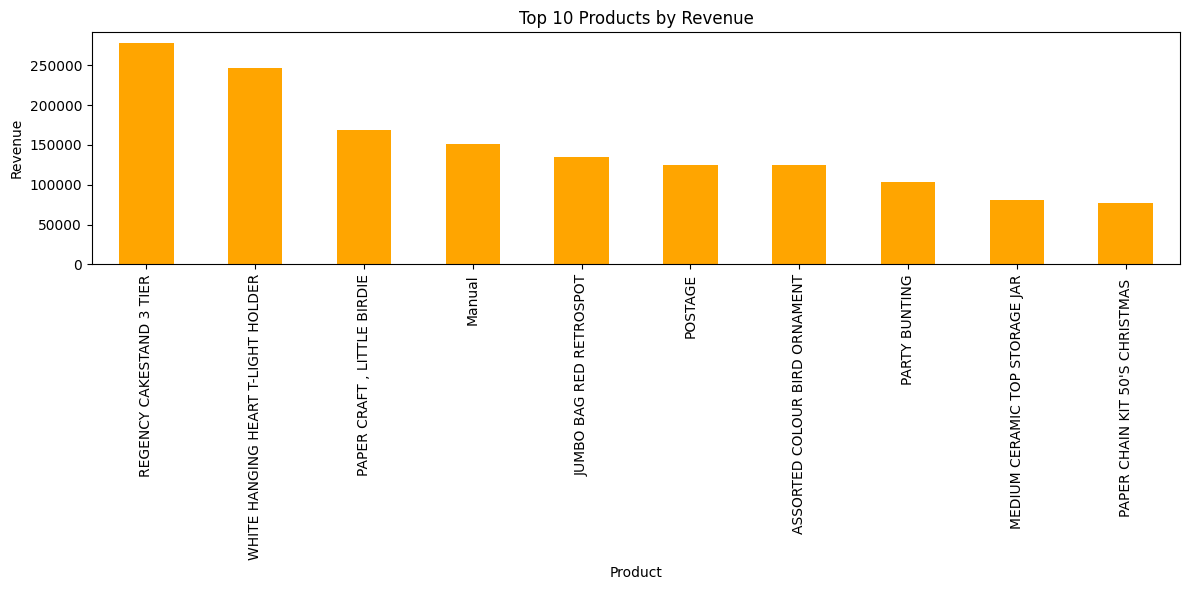

In [47]:
plt.figure(figsize=(12,6))
top_products.head(10).plot(kind="bar",color="orange")
plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

### Observation

The analysis identifies the top 10 products contributing the highest revenue.

These products represent the company's highest-performing items and are likely key revenue drivers.

### Business Insight

The company should prioritize inventory availability for these products and consider promoting them through marketing campaigns to maximize sales.

In [48]:
top_customers = (
    clean.groupby("Customer ID")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
)

top_customers.head(10)

Customer ID
18102.0    580987.04
14646.0    528602.52
14156.0    313437.62
14911.0    291420.81
17450.0    244784.25
13694.0    195640.69
17511.0    172132.87
16446.0    168472.50
16684.0    147142.77
12415.0    144458.37
Name: TotalPrice, dtype: float64

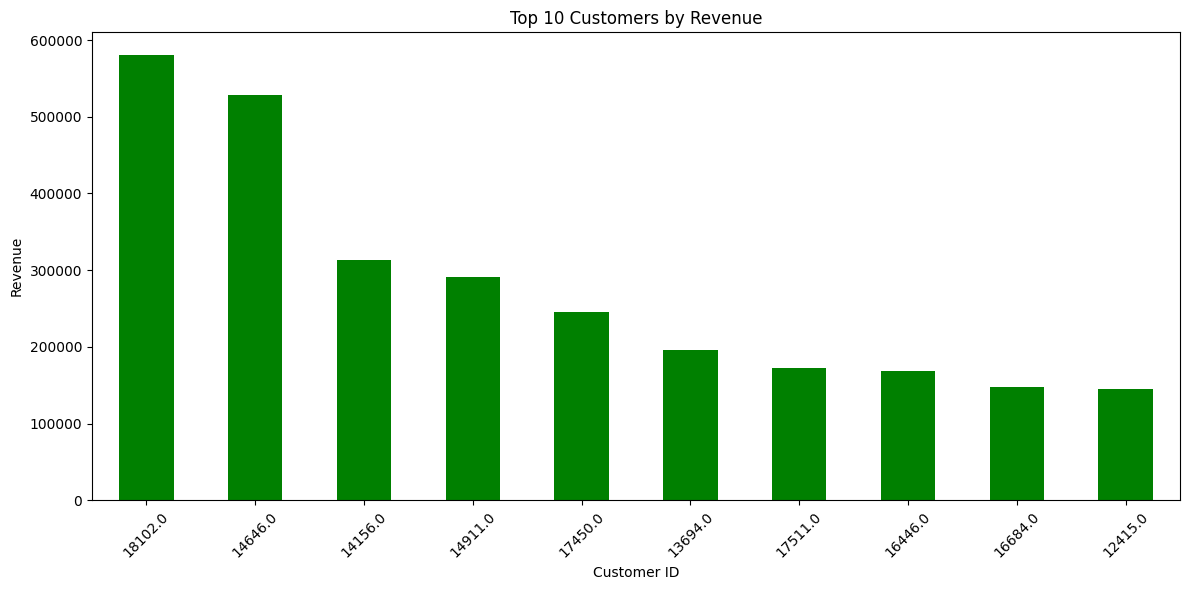

In [49]:
plt.figure(figsize=(12,6))
top_customers.head(10).plot(kind="bar",color="green")

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Observation

A small number of customers contribute a significant share of total revenue.

### Business Insight

These high-value customers should be prioritized through loyalty programs, personalized offers, and retention strategies since retaining them is likely to generate greater long-term revenue.

In [50]:
# mothly sales
clean["Month"]=clean["InvoiceDate"].dt.to_period("M")

In [51]:
monthly_sales=clean.groupby("Month")["TotalPrice"].sum()

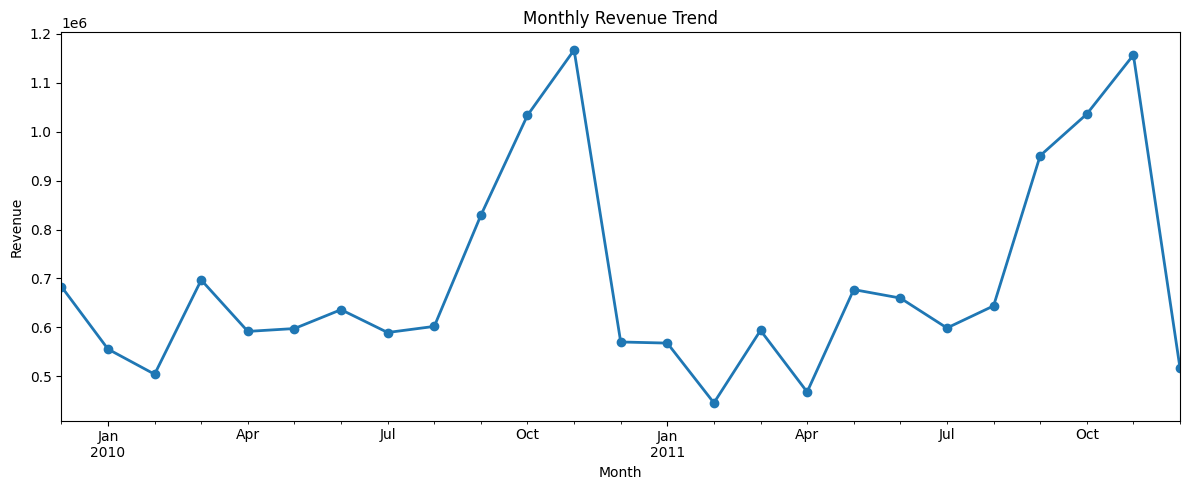

In [52]:
plt.figure(figsize=(12,5))
monthly_sales.plot(marker="o",linewidth=2)
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

Revenue increased steadily between July to December and August To December

The highest revenue occurred in October and November

Revenue dropped during January to April

In [53]:
clean["DayName"]=clean["InvoiceDate"].dt.day_name()
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

In [54]:
weekday_sales=(clean.groupby("DayName")["TotalPrice"].sum()
.reindex(weekday_order)
)

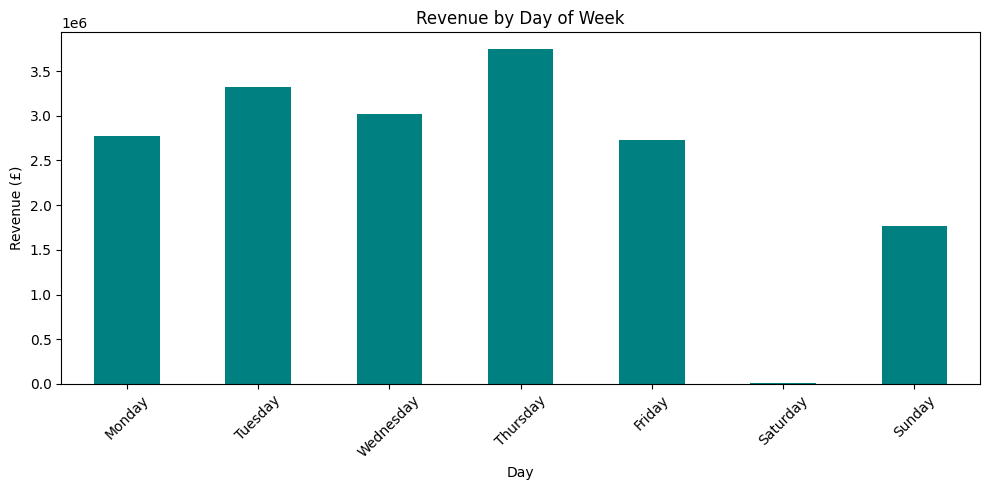

In [55]:
plt.figure(figsize=(10,5))

weekday_sales.plot(kind="bar",color="teal")

plt.title("Revenue by Day of Week")

plt.xlabel("Day")

plt.ylabel("Revenue (£)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

Thrusday generated the highest revenue.

Weekend sales were lower.

Revenue remained fairly consistent across weekdays.

In [56]:
monthly_orders=clean.groupby("Month")["Invoice"].nunique()

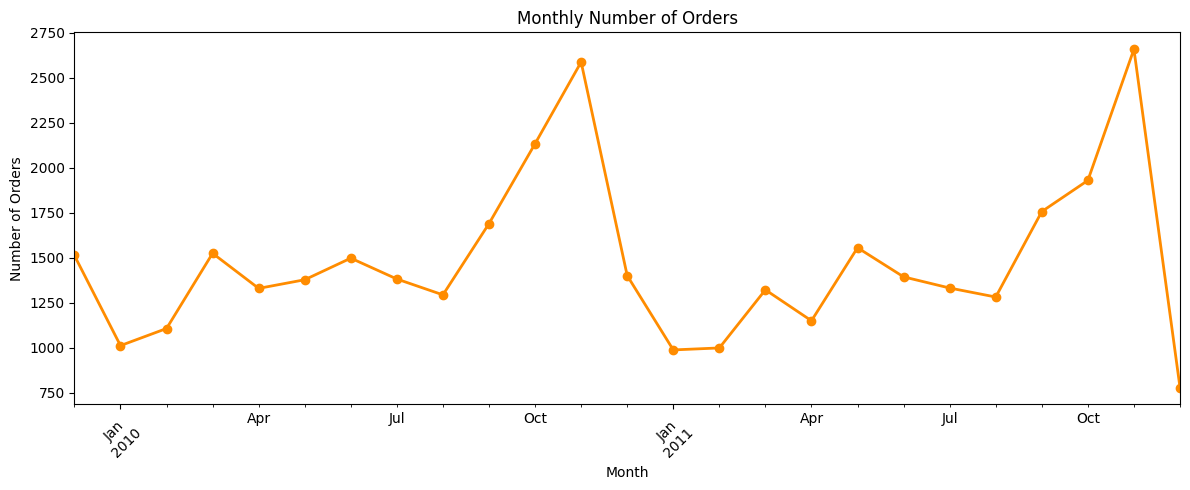

In [57]:
plt.figure(figsize=(12,5))

monthly_orders.plot(
    marker="o",
    linewidth=2,
    color="darkorange"
)

plt.title("Monthly Number of Orders")

plt.xlabel("Month")

plt.ylabel("Number of Orders")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [58]:
top_quantity=clean.groupby("Description")["Quantity"].sum().sort_values(ascending=False)

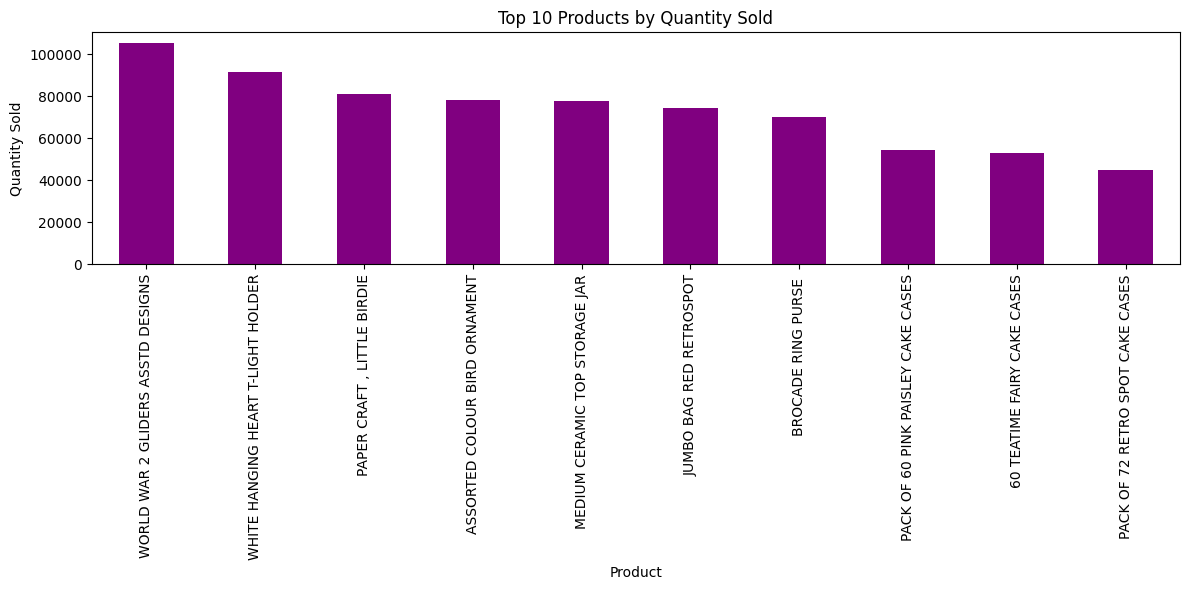

In [59]:
plt.figure(figsize=(12,6))

top_quantity.head(10).plot(
    kind="bar",
    color="purple"
)

plt.title("Top 10 Products by Quantity Sold")

plt.xlabel("Product")

plt.ylabel("Quantity Sold")

plt.xticks(rotation=90)

plt.tight_layout()

plt.show()

In [60]:
clean.to_csv("clean_data.csv", index=False)
clean.to_excel("clean_data.xlsx", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.
